In [4]:
import os
import importlib
import numpy as np, pandas as pd, networkx as nx
import Project1.A3.desikan_killiany_atlas as dkatlas
import Project1.A3.utils_a3 as utils
# import Project1.A3.watts_in_adni as nwm
from collections import defaultdict
import Project1.A3.utils_a1_a3 as utils_a1
# import Project1.A3.gudhi_persistence_a3 as gp_a1
import Project1.A1.network_science as nc

import re
import matplotlib.pyplot as plt
import lifelines
from sklearn.decomposition import PCA
import community as community_louvain
import warnings
PATH = os.getcwd()
BASE_DIR = utils.BASE_DIR
print(f"utils base directory: {BASE_DIR}")

utils base directory: C:\Users\sranasin\PycharmProjects\NetworkModels


In [6]:
# reload all
importlib.reload(utils)
    # ; # importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(nc)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'Project1.A3.desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [7]:
df = pd.read_csv(os.path.join(BASE_DIR, "resources", "adni_pet_image_analysis", "AMY", "Diagnostics_merged_amy_6mm.csv"))
df.head()

,LONIUID,PTID,RID,SCANDATE,QC_FLAG,TRACER,RH.LATERALORBITOFRONTAL,RH.PARSORBITALIS,RH.FRONTALPOLE,RH.MEDIALORBITOFRONTAL,...,LEFT-THALAMUS-PROPER,LEFT-CAUDATE,LEFT-PUTAMEN,LEFT-PALLIDUM,LEFT-ACCUMBENS-AREA,LEFT-HIPPOCAMPUS,LEFT-AMYGDALA,BRAIN-STEM,DIAGNOSIS_NAME,DATE_DIFF
0,1594517,011_S_0021,21,10/8/2010,2,FBP,1.128,1.060,0.902,0.985,...,1.159,1.132,1.197,1.392,1.010,1.016,0.924,1.397,CN,10 days
1,1594530,011_S_0021,21,10/3/2012,2,FBP,1.062,1.006,0.901,0.978,...,1.249,1.073,1.157,1.376,0.930,1.039,0.947,1.575,CN,8 days
2,1594602,011_S_0021,21,11/5/2015,2,FBP,1.002,0.987,0.925,0.931,...,1.175,1.018,1.155,1.470,0.862,1.019,0.864,1.493,CN,5 days
3,1594546,011_S_0021,21,11/28/2017,2,FBP,1.089,0.986,0.927,1.018,...,1.275,1.298,1.234,1.478,0.965,1.106,0.954,1.571,CN,90 days
4,10973799,011_S_0021,21,9/26/2024,-1,FBP,1.030,1.021,0.851,0.928,...,1.131,1.061,1.232,1.525,0.876,0.980,0.880,1.585,CN,59 days


In [8]:

# --- 1. Filter ---

# Parse "15 days" → 15
df['DATE_DIFF_NUM'] = df['DATE_DIFF'].str.extract(r'(\d+)').astype(float)

df_filtered = df[
    (df['QC_FLAG'] >= 2) &
    (df['DATE_DIFF_NUM'] <= 60) &
    (df['TRACER'] == 'FBP')
]

# --- 2. Define region columns ---
meta_cols = ['DIAGNOSIS_NAME', 'QC_FLAG', 'DATE_DIFF', 'TRACER', 'LONIUID', 'PTID', 'SCANDATE', 'DATE_DIFF_NUM']  # adjust as needed
region_cols = [c for c in df_filtered.columns if c not in meta_cols]

# --- 3. Mean SUVr per diagnosis group per region ---
group_means = df_filtered.groupby('DIAGNOSIS_NAME')[region_cols].mean()
# Shape: (n_diagnoses, n_regions)

# --- 4. Binarize at threshold 1.08 ---
THRESHOLD = 1.17
group_binary = (group_means >= THRESHOLD).astype(int)

In [9]:
group_binary

,RID,RH.LATERALORBITOFRONTAL,RH.PARSORBITALIS,RH.FRONTALPOLE,RH.MEDIALORBITOFRONTAL,RH.PARSTRIANGULARIS,RH.PARSOPERCULARIS,RH.ROSTRALMIDDLEFRONTAL,RH.SUPERIORFRONTAL,RH.CAUDALMIDDLEFRONTAL,...,LH.TRANSVERSETEMPORAL,LH.INSULA,LEFT-THALAMUS-PROPER,LEFT-CAUDATE,LEFT-PUTAMEN,LEFT-PALLIDUM,LEFT-ACCUMBENS-AREA,LEFT-HIPPOCAMPUS,LEFT-AMYGDALA,BRAIN-STEM
DIAGNOSIS_NAME,,,,,,,,,,,,,,,,,,,,,
AD,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,0,1
CN,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,1
MCI,1,1,1,0,1,1,1,1,1,1,...,0,0,1,0,1,1,0,0,0,1


In [10]:
graph_file_rel_path = os.path.join("resources", "base_data", "DKATLAS33_all.graphml")
graph = nx.read_graphml(os.path.join(utils.BASE_DIR, graph_file_rel_path))
nx.relabel_nodes(graph, lambda x: int(x), copy=False)

In [11]:
graph.nodes[1]

{'dn_position_x': 34.0419230769,
 'dn_position_y': 82.1757692308,
 'dn_position_z': 31.7769230769,
 'dn_correspondence_id': 1,
 'dn_region': 'cortical',
 'dn_fsname': 'lateralorbitofrontal',
 'dn_name': 'rh.lateralorbitofrontal',
 'dn_hemisphere': 'right',
 'region_name': 'rh_lateralorbitofrontal'}

In [12]:
# --- Clean region column names ---
# Your current columns are uppercase versions of the keys, e.g. 'RH.LATERALORBITOFRONTAL'
# Step 1: lowercase them, Step 2: map to dict values
DK_FSNAMES_MAPPING_DICT = utils.DK_FSNAMES_MAPPING_DICT

col_rename = {}
for col in region_cols:
    if col.lower() in DK_FSNAMES_MAPPING_DICT:
        # Handles cortical regions: 'RH.LATERALORBITOFRONTAL' -> lowercase -> match
        col_rename[col] = DK_FSNAMES_MAPPING_DICT[col.lower()]
    elif col.title() in DK_FSNAMES_MAPPING_DICT:
        # Handles subcortical regions: 'Left-Thalamus-Proper' -> exact match
        col_rename[col] = DK_FSNAMES_MAPPING_DICT[col.title()]

group_binary = group_binary.rename(columns=col_rename)

group_binary = group_binary.rename(columns=col_rename)
group_binary
# Now column names match the 'region_name' node attribute in your graph

,RID,rh_lateralorbitofrontal,rh_parsorbitalis,rh_frontalpole,rh_medialorbitofrontal,rh_parstriangularis,rh_parsopercularis,rh_rostralmiddlefrontal,rh_superiorfrontal,rh_caudalmiddlefrontal,...,lh_transversetemporal,lh_insula,lh_thalamus_proper,lh_caudate,lh_putamen,lh_pallidum,LEFT-ACCUMBENS-AREA,lh_hippocampus,lh_amygdala,brainstem
DIAGNOSIS_NAME,,,,,,,,,,,,,,,,,,,,,
AD,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,0,1
CN,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,1
MCI,1,1,1,0,1,1,1,1,1,1,...,0,0,1,0,1,1,0,0,0,1


In [13]:
import networkx as nx
from networkx.algorithms import community
import pandas as pd

def build_diagnosis_subgraph(G, binary_row):
    """
    G          : full DK connectome with node attr 'region_name'
    binary_row : pd.Series with region_name -> 0/1 activation
    """
    # Activated regions for this diagnosis
    activated = set(binary_row[binary_row == 1].index)

    # Get nodes whose 'region_name' is in activated set
    active_nodes = [n for n, attr in G.nodes(data=True)
                    if attr.get('region_name') in activated]

    # Subgraph: edges kept only if BOTH endpoints are active
    subG = G.subgraph(active_nodes).copy()
    return subG


def compute_node_properties(subG):
    """Returns a DataFrame of per-node metrics for a subgraph."""
    if len(subG) == 0:
        return pd.DataFrame()

    # Community detection (needed for modularity + participation)
    comms = community.greedy_modularity_communities(subG)
    node_to_comm = {n: i for i, c in enumerate(comms) for n in c}

    # Modularity (graph-level, broadcast to all nodes)
    mod = community.modularity(subG, comms)

    # Node-level metrics
    closeness  = nx.closeness_centrality(subG)
    strength   = dict(subG.degree(weight='weight'))
    clustering = nx.clustering(subG, weight='weight')

    # Participation coefficient
    def participation(G, node_to_comm):
        P = {}
        for node in G.nodes():
            k_i = G.degree(node, weight='weight')
            if k_i == 0:
                P[node] = 0
                continue
            comm_w = {}
            for nb in G.neighbors(node):
                c = node_to_comm[nb]
                comm_w[c] = comm_w.get(c, 0) + G[node][nb].get('weight', 1)
            P[node] = 1 - sum((w / k_i) ** 2 for w in comm_w.values())
        return P

    participation_coef = participation(subG, node_to_comm)

    df = pd.DataFrame({
        'region_name' : [subG.nodes[n].get('region_name') for n in subG.nodes()],
        'closeness'   : [closeness[n]          for n in subG.nodes()],
        'strength'    : [strength[n]           for n in subG.nodes()],
        'clustering'  : [clustering[n]         for n in subG.nodes()],
        'participation': [participation_coef[n] for n in subG.nodes()],
        'modularity'  : mod,   # same value for all rows (graph-level)
        'community'   : [node_to_comm[n]       for n in subG.nodes()],
    })
    return df


# --- Run for all three diagnosis groups ---
results = {}
subgraphs = {}

for diagnosis in ['CN', 'MCI', 'AD']:
    binary_row = group_binary.loc[diagnosis]
    subG = build_diagnosis_subgraph(graph, binary_row)
    subgraphs[diagnosis] = subG
    results[diagnosis] = compute_node_properties(subG)
    print(f"{diagnosis}: {subG.number_of_nodes()} nodes, {subG.number_of_edges()} edges")

CN: 19 nodes, 111 edges
MCI: 45 nodes, 556 edges
AD: 71 nodes, 1265 edges


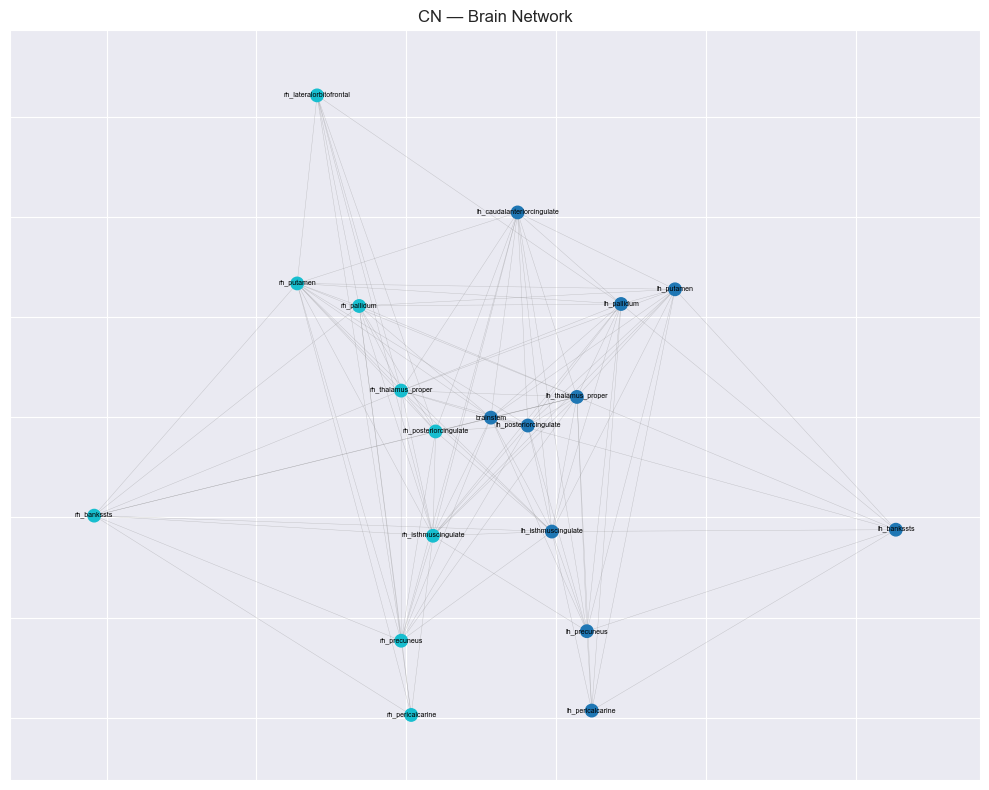

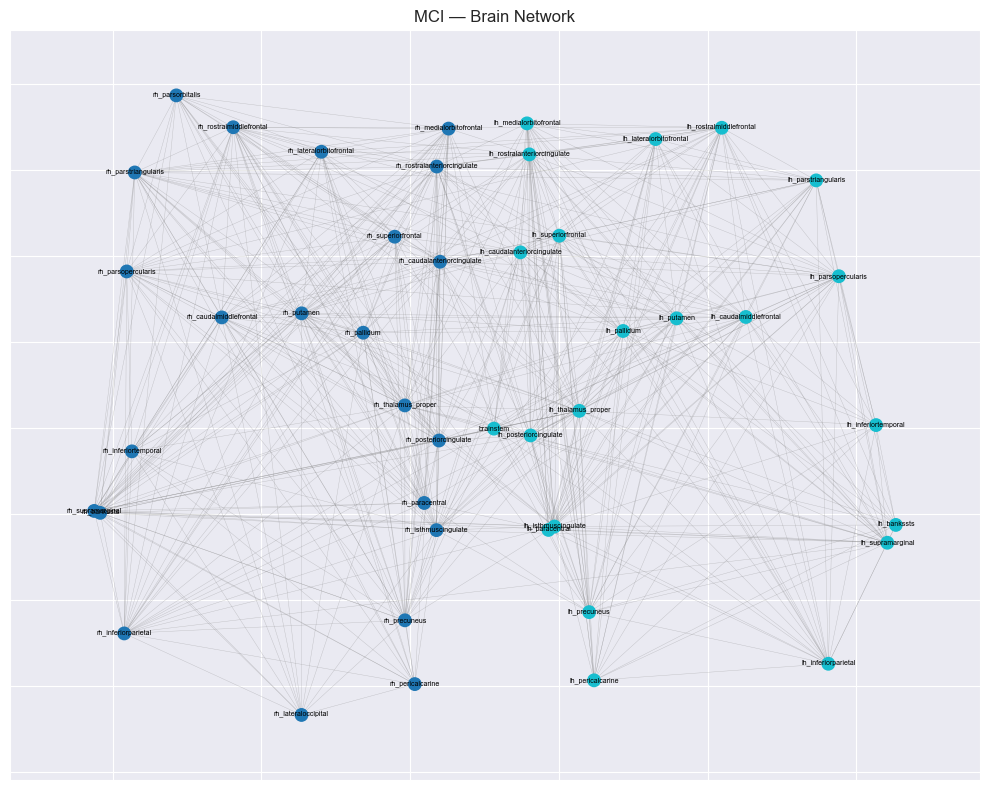

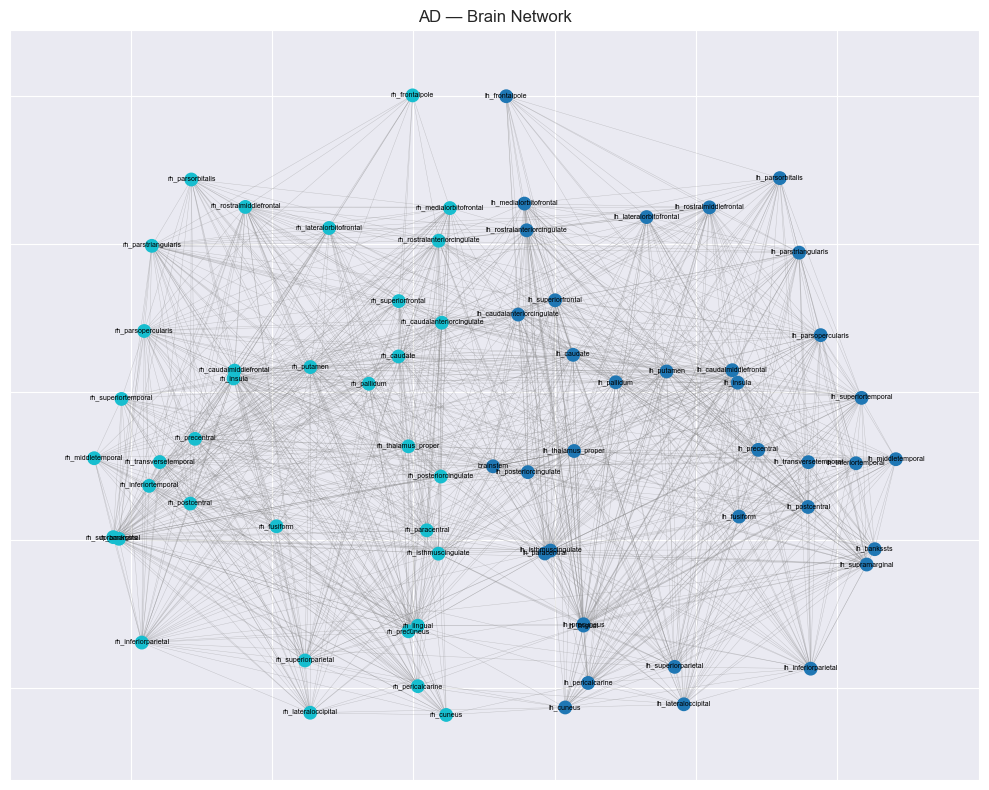

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_network(subG, title):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Extract 2D positions from x, y node attributes (drop z or use x,z for axial view)
    pos = {n: (attr['dn_position_x'], attr['dn_position_y']) for n, attr in subG.nodes(data=True)}

    comms = community.greedy_modularity_communities(subG)
    node_to_comm = {n: i for i, c in enumerate(comms) for n in c}
    colors = [node_to_comm[n] for n in subG.nodes()]

    weights = [subG[u][v].get('weight', 1) for u, v in subG.edges()]
    w_arr = np.array(weights)
    w_norm = (w_arr - w_arr.min()) / (np.ptp(w_arr) + 1e-9)  # normalize to [0,1]

    nx.draw_networkx_nodes(subG, pos, node_color=colors, cmap=cm.tab10,
                           node_size=80, ax=ax)
    nx.draw_networkx_edges(subG, pos, width=w_norm * 2 + 0.3,
                           alpha=0.4, edge_color='gray', ax=ax)
    nx.draw_networkx_labels(subG, pos,
                            labels={n: subG.nodes[n].get('region_name', n) for n in subG.nodes()},
                            font_size=5, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

for diag, subG in subgraphs.items():
    plot_network(subG, f"{diag} — Brain Network")

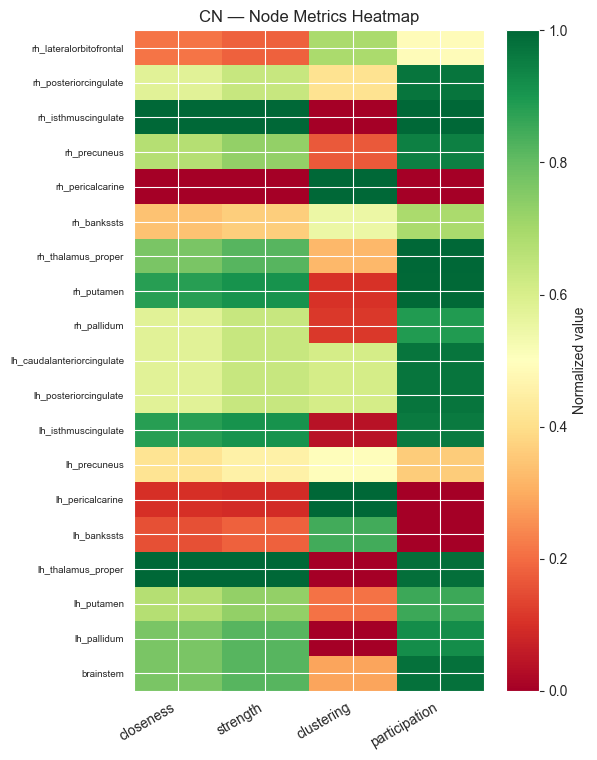

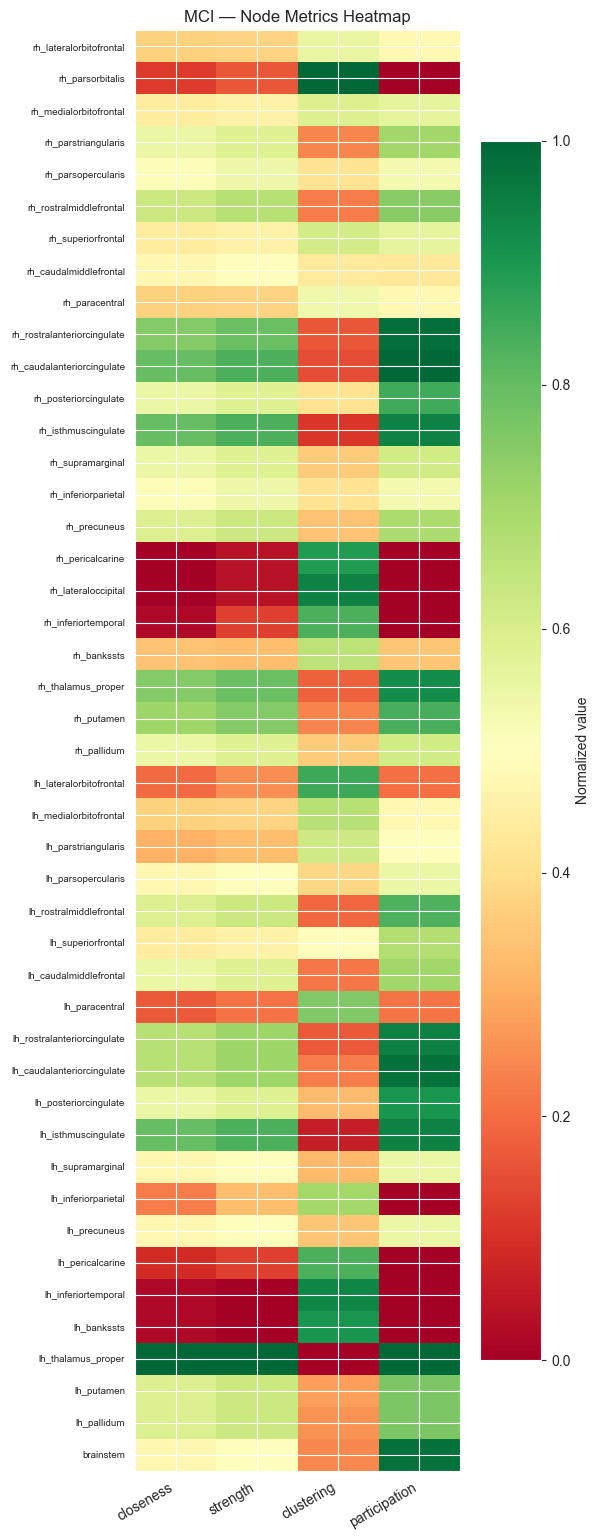

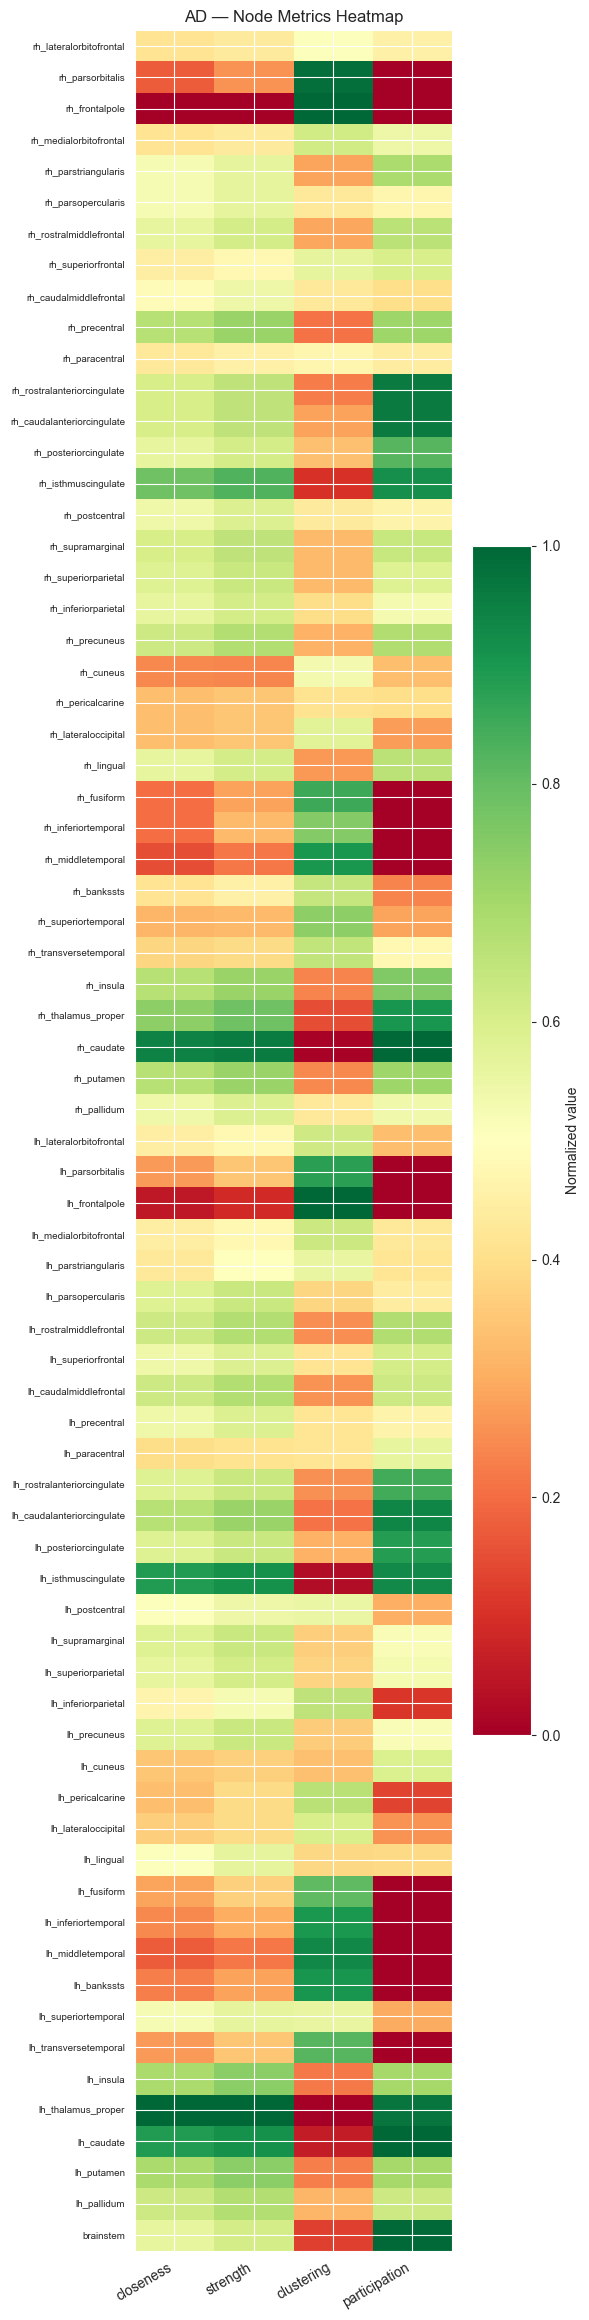

In [15]:
def plot_heatmap(results, diagnosis):
    df = results[diagnosis].set_index('region_name')
    metrics = ['closeness', 'strength', 'clustering', 'participation']

    fig, ax = plt.subplots(figsize=(6, len(df) * 0.3 + 2))

    data = df[metrics]
    # Normalize each metric to [0,1] for comparable coloring
    data_norm = (data - data.min()) / (data.max() - data.min() + 1e-9)

    im = ax.imshow(data_norm.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, rotation=30, ha='right')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df.index, fontsize=7)
    plt.colorbar(im, ax=ax, label='Normalized value')
    ax.set_title(f"{diagnosis} — Node Metrics Heatmap")
    plt.tight_layout()
    plt.show()

for diag in ['CN', 'MCI', 'AD']:
    plot_heatmap(results, diag)

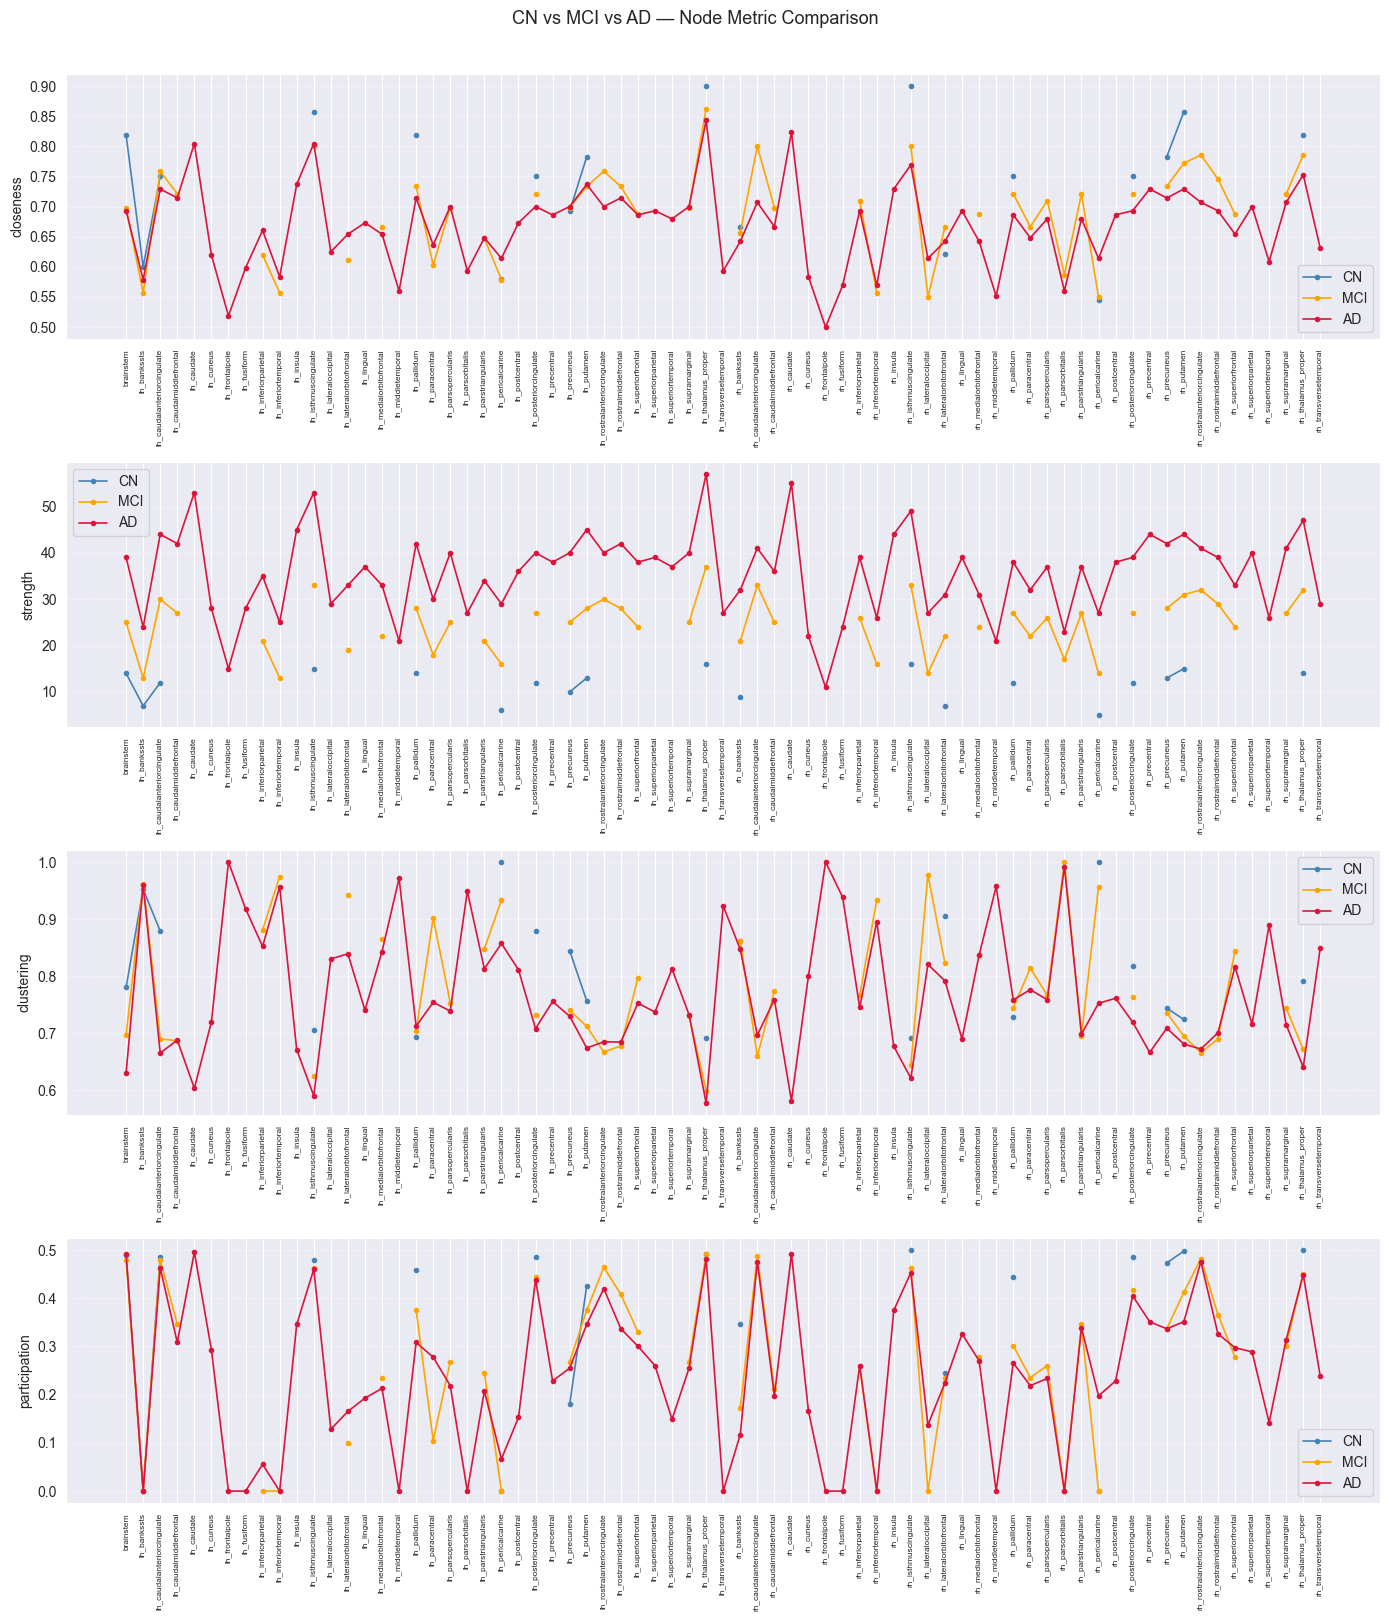

In [16]:
def plot_comparison(results):
    metrics = ['closeness', 'strength', 'clustering', 'participation']

    # Align all diagnoses on the same regions
    all_regions = sorted(set(
        r for df in results.values() for r in df['region_name']
    ))

    # Build a (metric, diagnosis) grid
    fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 4 * len(metrics)), sharex=False)

    for ax, metric in zip(axes, metrics):
        for diag, color in zip(['CN', 'MCI', 'AD'], ['steelblue', 'orange', 'crimson']):
            df = results[diag].set_index('region_name')[metric].reindex(all_regions)
            ax.plot(all_regions, df.values, marker='o', label=diag,
                    color=color, linewidth=1.2, markersize=3)

        ax.set_ylabel(metric)
        ax.set_xticks(range(len(all_regions)))
        ax.set_xticklabels(all_regions, rotation=90, fontsize=6)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    fig.suptitle('CN vs MCI vs AD — Node Metric Comparison', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_comparison(results)

#### ANOVA basic

In [17]:
df = pd.read_csv(os.path.join(BASE_DIR, "resources", "tthompson_adni", "structured_files_av45-diagnostics-STATUS", "av45-diagnostics-STATUS_suvr.csv"))
df.head()

,rid,examdate,pdx,status,apoe4,age,gender,rh.lateralorbitofrontal,rh.parsorbitalis,rh.frontalpole,...,lh.transversetemporal,lh.insula,Left-Thalamus-Proper,Left-Caudate,Left-Putamen,Left-Pallidum,Left-Accumbens-area,Left-Hippocampus,Left-Amygdala,Brain-Stem
0,21,2010-10-08,CN,NEG,NEG,77,F,1.3479,1.3011,1.1000,...,1.2883,1.2734,1.4449,1.4032,1.5116,1.6622,1.2228,1.2937,1.1618,1.6384
1,21,2012-10-03,CN,NEG,NEG,79,F,1.4567,1.3479,1.1520,...,1.3255,1.3082,1.6174,1.4689,1.5773,1.8511,1.2238,1.4162,1.2589,1.9818
2,21,2015-11-05,CN,NEG,NEG,82,F,1.2973,1.2841,1.1556,...,1.3027,1.2308,1.4412,1.3651,1.5266,1.8509,1.0866,1.3233,1.1432,1.8233
3,21,2017-11-28,CN,NEG,NEG,84,F,1.4156,1.2542,1.1247,...,1.4034,1.3108,1.5581,1.5978,1.5540,1.8079,1.2257,1.4005,1.2073,1.8749
4,23,2010-12-21,CN,NEG,NEG,76,M,1.2720,1.1151,1.0001,...,1.3372,1.2529,1.4564,1.4232,1.5732,1.9062,1.1994,1.4917,1.3463,1.7559


In [18]:
from scipy.stats import chi2_contingency
import pandas as pd

# --- Define variable types ---
continuous_vars   = ['age']          # adjust
categorical_vars  = ['gender', 'apoe4', 'status'] # adjust

In [19]:
# --- Chi-square for categorical variables ---
cat_rows = []

for var in categorical_vars:
    contingency = pd.crosstab(df[var], df['pdx'])  # rows=categories, cols=diagnosis
    chi2, p_val, dof, expected = chi2_contingency(contingency)

    cat_rows.append({
        'variable'   : var,
        'test'       : 'chi-square',
        'statistic'  : round(chi2, 3),
        'df'         : dof,
        'p_value'    : round(p_val, 4),
        'significant': 'Yes' if p_val < 0.05 else 'No'
    })

chi2_summary = pd.DataFrame(cat_rows)
print(chi2_summary.to_string(index=False))

variable       test  statistic  df  p_value significant
  gender chi-square     37.899   2      0.0         Yes
   apoe4 chi-square    150.409   2      0.0         Yes
  status chi-square    419.109   2      0.0         Yes


In [20]:
# --- Post-hoc for significant categorical: pairwise chi-square with Bonferroni ---
from itertools import combinations
from scipy.stats import chi2_contingency

sig_cat_vars = chi2_summary[chi2_summary['significant'] == 'Yes']['variable'].tolist()
diag_pairs = list(combinations(['CN', 'MCI', 'AD'], 2))

for var in sig_cat_vars:
    print(f"\n--- Pairwise Chi-square (Bonferroni): {var} ---")
    pair_rows = []
    for d1, d2 in diag_pairs:
        sub = df[df['pdx'].isin([d1, d2])]
        ct  = pd.crosstab(sub[var], sub['pdx'])
        chi2, p_val, _, _ = chi2_contingency(ct)
        p_corrected = min(p_val * len(diag_pairs), 1.0)  # Bonferroni correction
        pair_rows.append({
            'comparison' : f'{d1} vs {d2}',
            'chi2'       : round(chi2, 3),
            'p_raw'      : round(p_val, 4),
            'p_bonferroni': round(p_corrected, 4),
            'significant': 'Yes' if p_corrected < 0.05 else 'No'
        })
    print(pd.DataFrame(pair_rows).to_string(index=False))


--- Pairwise Chi-square (Bonferroni): gender ---
comparison   chi2  p_raw  p_bonferroni significant
 CN vs MCI 34.190 0.0000        0.0000         Yes
  CN vs AD 13.753 0.0002        0.0006         Yes
 MCI vs AD  0.196 0.6578        1.0000          No

--- Pairwise Chi-square (Bonferroni): apoe4 ---
comparison    chi2  p_raw  p_bonferroni significant
 CN vs MCI  33.100    0.0           0.0         Yes
  CN vs AD 148.487    0.0           0.0         Yes
 MCI vs AD  61.118    0.0           0.0         Yes

--- Pairwise Chi-square (Bonferroni): status ---
comparison    chi2  p_raw  p_bonferroni significant
 CN vs MCI  98.751    0.0           0.0         Yes
  CN vs AD 411.953    0.0           0.0         Yes
 MCI vs AD 176.113    0.0           0.0         Yes


In [ ]:
# --- Re-run ANOVA for continuous variables ---
rows = []

for var in continuous_vars:
    samples = [g[var].dropna().values for g in groups]

    f_stat, p_val = stats.f_oneway(*samples)

    all_vals = pd.concat([g[var].dropna() for g in groups])
    grand_mean = all_vals.mean()
    ss_between = sum(len(s) * (s.mean() - grand_mean) ** 2 for s in samples)
    ss_total   = sum((all_vals - grand_mean) ** 2)
    eta_sq     = ss_between / ss_total if ss_total > 0 else float('nan')

    rows.append({
        'variable'   : var,
        'test'       : 'ANOVA',
        'statistic'  : round(f_stat, 3),
        'df'         : '-',
        'p_value'    : round(p_val, 4),
        'eta_sq'     : round(eta_sq, 3),
        'significant': 'Yes' if p_val < 0.05 else 'No'
    })

anova_summary = pd.DataFrame(rows)

In [ ]:
anova_summary

In [ ]:
# --- Combine both summaries into one master table ---
anova_summary['df'] = '-'  # ANOVA doesn't report df the same way
anova_summary = anova_summary.rename(columns={'F': 'statistic'})
anova_summary['test'] = 'ANOVA'

master_summary = pd.concat([anova_summary, chi2_summary], ignore_index=True)
master_summary = master_summary[['variable', 'test', 'statistic', 'df', 'p_value', 'significant']]
print(master_summary.to_string(index=False))

In [ ]:
print(master_summary.to_latex(index=False, caption="Group comparisons across diagnostic categories (CN, MCI, AD)", label="tab:anova_chi2"))

see this commented link <!-- ![image.png](attachment:09657023-5201-4932-a1fd-63840eb23d14.png) -->

In [ ]:
import os
import utils_a3 as utils
import importlib
import pandas as pd
import numpy as np



In [ ]:
df_features = pd.read_csv(os.path.join(utils.BASE_DIR, "resources", "tthompson_adni", "av1451-diagnostics-STATUS.csv"), usecols = ['RID', 'EXAMDATE', 'PDX', 'APOE4', 'AGE', 'GENDER', 'STATUS'])
df_features.head()

In [ ]:
df_data = pd.read_csv(os.path.join(utils.BASE_DIR, "resources/adni_pet_image_analysis/AMY/Diagnostics_merged_amy_6mm.csv"))
df_data.drop(columns = ['DIAGNOSIS_NAME', 'DATE_DIFF'], axis = 1, inplace=True)
df_data.head()

In [ ]:
df = utils.merge_nearest_date(left_df = df_data, right_df = df_features, left_date = 'SCANDATE', right_date = 'EXAMDATE', on='RID')
df['DATE_DIFF'] = (df['SCANDATE'] - df['EXAMDATE']).abs()
df.head()

In [ ]:
df_control = df[
    (df['AGE'] >=60 ) &
    (df['PDX'] == 'CN') &
    (df['DATE_DIFF'] <= pd.Timedelta(days = 60)) &
    (df['STATUS'] == 'NEG') &
    (df['TRACER'] == 'FBP') &
    (df['QC_FLAG'] >= 2)
]

In [ ]:
## keep only 1 row from filtered, with least date diff
#
df_control = (
    df_control.sort_values('DATE_DIFF')
      .drop_duplicates(subset='RID', keep='first')
      .reset_index(drop=True)
)

In [ ]:
df_control.shape

In [ ]:
region_columns = set(df.columns) - {'LONIUID', 'RID', 'PTID', 'SCANDATE', 'QC_FLAG', 'TRACER', 'EXAMDATE', 'PDX', 'AGE', 'APOE4', 'GENDER', 'STATUS', 'DATE_DIFF'}
DK_region_names = [k.upper() for k in utils.DK_FSNAMES_MAPPING_DICT.keys()]

# set(DK_region_names) - set(region_cols)
set(region_cols) - set(DK_region_names)
cleaned_dict = {
    (k.lower() if '-' in k else k): v
    for k, v in utils.DK_FSNAMES_MAPPING_DICT.items()
}
cleaned_dict

In [ ]:
region_means = {
    cleaned_dict[col.lower()]: df_control[col].mean()
    for col in region_columns
    if col in DK_region_names
}

region_sds = {
    cleaned_dict[col.lower()]: df_control[col].std()
    for col in region_columns
    if col in DK_region_names
}

In [ ]:
# Create ordered arrays based on NODE_FSREGION_TO_ID
n = len(utils.NODE_FSREGION_TO_ID)
means_array = np.zeros(n)
sds_array = np.zeros(n)

for region, idx in utils.NODE_FSREGION_TO_ID.items():
    means_array[idx - 1] = region_means.get(region, np.nan)
    sds_array[idx - 1] = region_sds.get(region, np.nan)

min_sd = 0.01
sds_array = np.maximum(sds_array, min_sd)

In [ ]:
rename_dict = {
    key.upper(): key for key, value in cleaned_dict.items()
}

df.rename(columns=rename_dict, inplace=True)
df.rename(columns=cleaned_dict, inplace=True)
df.head()

In [ ]:
[k for k in df.columns if k in utils.NODE_FSREGION_TO_ID.keys()]

In [130]:
### TEst above score for some patients

df_patients_raw = df[~df['RID'].isin(df_control['RID'].unique())].copy()
df_patients = df_patients_raw[
    (df_patients_raw['QC_FLAG'] >= 2) &
    (df_patients_raw['DATE_DIFF'] <= pd.Timedelta(days = 60)) &
     (df_patients_raw['TRACER'] == 'FBP')
].copy()

ordered_regions = list(utils.NODE_FSREGION_TO_ID.keys())
patient_matrix = df_patients[ordered_regions].to_numpy()


z_scores = (patient_matrix - means_array) / sds_array
df_patients['ZSCORE_SUM'] = z_scores.sum(axis=1)

In [131]:
df_patients

,LONIUID,PTID,RID,SCANDATE,QC_FLAG,TRACER,rh_lateralorbitofrontal,rh_parsorbitalis,rh_frontalpole,rh_medialorbitofrontal,...,lh_amygdala,brainstem,EXAMDATE,PDX,APOE4,AGE,GENDER,STATUS,DATE_DIFF,ZSCORE_SUM
10,1596222,023_S_0031,31,2018-04-18,2,FBP,1.593,1.467,1.506,1.558,...,1.133,1.416,2018-04-24,CN,NEG,90.0,F,POS,6 days,354.410380
21,1598978,067_S_0056,56,2019-12-04,2,FBP,0.992,0.911,0.796,0.883,...,0.930,1.714,2019-12-03,MCI,NEG,83.0,F,NEG,1 days,-48.308213
27,1598979,067_S_0059,59,2017-12-20,2,FBP,1.160,0.982,0.795,0.917,...,1.068,1.680,2017-12-12,MCI,NEG,82.0,F,NEG,8 days,0.223645
36,1600126,100_S_0069,69,2020-01-23,2,FBP,1.082,1.014,0.840,0.985,...,0.989,1.560,2020-02-05,MCI,NEG,87.0,M,NEG,13 days,-18.524587
71,1596705,027_S_0120,120,2017-09-26,2,FBP,1.123,1.057,0.910,0.970,...,1.004,1.543,2017-09-13,CN,POS,83.0,M,POS,13 days,111.338214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4069,1614283,035_S_6999,6999,2021-09-21,2,FBP,1.409,1.237,0.952,1.200,...,1.077,1.322,2021-09-23,CN,NaN,70.0,M,POS,2 days,249.049752
4070,1614287,035_S_7000,7000,2021-10-04,2,FBP,1.111,0.960,0.815,0.975,...,0.995,1.498,2021-10-13,MCI,NaN,89.0,F,NEG,9 days,-0.712882
4071,1614244,035_S_7004,7004,2021-11-16,2,FBP,1.162,1.050,0.814,1.039,...,1.071,1.580,2021-11-02,CN,NaN,56.0,F,NEG,14 days,19.496192
4076,1610483,003_S_7010,7010,2021-11-02,2,FBP,1.199,1.132,0.870,1.077,...,1.084,1.432,2021-10-28,CN,NaN,59.0,M,NEG,5 days,66.407219


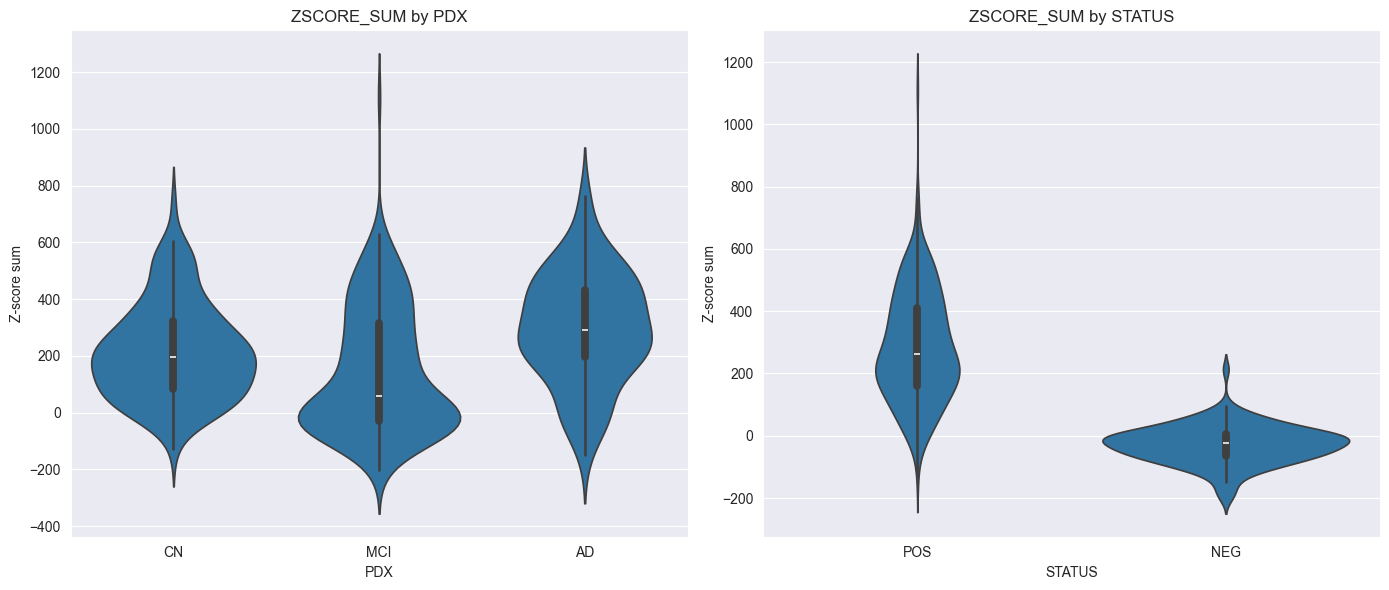

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

df_viz = df_patients[
    (df_patients['QC_FLAG'] >= 2) &
    (df_patients['DATE_DIFF'] <= pd.Timedelta(days=60))
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df_viz, x='PDX', y='ZSCORE_SUM', inner='box', ax=axes[0])
axes[0].set_title('ZSCORE_SUM by PDX')
axes[0].set_xlabel('PDX')
axes[0].set_ylabel('Z-score sum')

sns.violinplot(data=df_viz, x='STATUS', y='ZSCORE_SUM', inner='box', ax=axes[1])
axes[1].set_title('ZSCORE_SUM by STATUS')
axes[1].set_xlabel('STATUS')
axes[1].set_ylabel('Z-score sum')

plt.tight_layout()
plt.show()

In [ ]:
df_patients.sort_values('ZSCORE_SUM', ascending=False)

In [ ]:
sds_array

In [ ]:
means_array

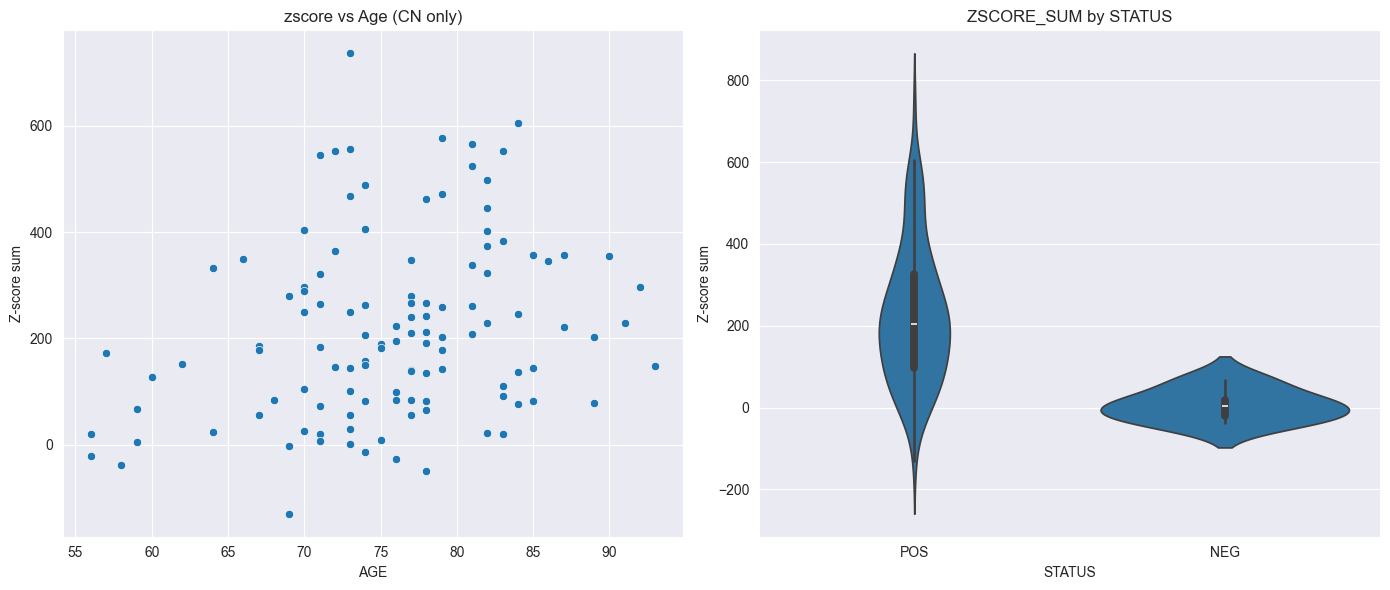

In [153]:
df_check_cn = df_patients[df_patients['PDX'] == 'CN'].sort_values('ZSCORE_SUM', ascending=False).copy()
df_check_cn.head()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df_check_cn, x='AGE', y='ZSCORE_SUM', ax=axes[0])
axes[0].set_title('zscore vs Age (CN only)')
axes[0].set_xlabel('AGE')
axes[0].set_ylabel('Z-score sum')

sns.violinplot(data=df_check_cn, x='STATUS', y='ZSCORE_SUM', inner='box', ax=axes[1])
axes[1].set_title('ZSCORE_SUM by STATUS')
axes[1].set_xlabel('STATUS')
axes[1].set_ylabel('Z-score sum')

plt.tight_layout()
plt.show()